# 08.1 — Renorm vs Stale Comparison (All 8 Experiments)

Mirrors the structure of [08_cross_experiment_evaluation.ipynb](08_cross_experiment_evaluation.ipynb) but compares two **run families** side by side:

- **stale** — the original preprocessing (human-only HVG, mismatched normalization, `evals_ood_data_space`)
- **renorm** — the canonical cross-species pipeline from [01.3_data_prep_all_holdouts_renorm.ipynb](01.3_data_prep_all_holdouts_renorm.ipynb): identical `normalize_total`+`log1p` on raw counts for both species, HVG with `batch_key="species"`, `evals_ood_latent_space`

Each family has 4 holdout groups x 2 CellOT-family models (swapped CellOT = IMPACT, Normal CellOT = paper-style CellOT), giving 8 runs per family, 16 total.

### Terminology mapping

| Column label in this notebook | Semantic | Stale subdir | Renorm subdir |
|---|---|---|---|
| **IMPACT** | Species transport (mouse -> human, `condition=species`) | `impact_or`, `speciesot_cellot` | `swapped_cellot` |
| **CellOT** | Cell-type-status transport (non_X -> X, paper-style) | `cellot`, `speciesot_cellot_swapped` | `normal_cellot` |

Labels match notebook 08 for direct comparability.

### Metric notes

- `r2_means` / `r2_stds` in `evals.csv` are raw Pearson r, squared here to get actual R².
- Stale eval ran with `--where data_space`; renorm eval ran with `--where latent_space`. Both report OOD metrics at the same `max(ncells)` subsample.
- Higher R² = better; lower MMD = better.

In [1]:
import sys
sys.path.insert(0, "/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import sparse

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 220)

CELLOT_GPU = Path("/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu")

# --- Stale run family (original preprocessing; evals in data_space) ---
GROUPS_STALE = {
    'A': {'label': 'CD8 only',        'results_dir': 'speciesot_cd8',            'impact_subdir': 'impact_or',        'cellot_subdir': 'cellot',                   'scgen_subdir': 'speciesot_scgen', 'evals_sub': 'evals_ood_data_space'},
    'B': {'label': 'CD8 (no thymo)',  'results_dir': 'speciesot_cd8_nothymo',    'impact_subdir': 'speciesot_cellot', 'cellot_subdir': 'speciesot_cellot_swapped', 'scgen_subdir': 'speciesot_scgen', 'evals_sub': 'evals_ood_data_space'},
    'C': {'label': 'T cell subtypes', 'results_dir': 'speciesot_tcell_subtypes', 'impact_subdir': 'speciesot_cellot', 'cellot_subdir': 'speciesot_cellot_swapped', 'scgen_subdir': 'speciesot_scgen', 'evals_sub': 'evals_ood_data_space'},
    'D': {'label': 'CD4 only',        'results_dir': 'speciesot_cd4',            'impact_subdir': 'speciesot_cellot', 'cellot_subdir': 'speciesot_cellot_swapped', 'scgen_subdir': 'speciesot_scgen', 'evals_sub': 'evals_ood_data_space'},
}

# --- Renorm run family (canonical cross-species preprocessing; evals in latent_space) ---
GROUPS_RENORM = {
    'A': {'label': 'CD8 only',        'results_dir': 'renorm_cd8',            'impact_subdir': 'swapped_cellot', 'cellot_subdir': 'normal_cellot', 'scgen_subdir': 'scgen', 'evals_sub': 'evals_ood_latent_space'},
    'B': {'label': 'CD8 (no thymo)',  'results_dir': 'renorm_cd8_thymo',      'impact_subdir': 'swapped_cellot', 'cellot_subdir': 'normal_cellot', 'scgen_subdir': 'scgen', 'evals_sub': 'evals_ood_latent_space'},
    'C': {'label': 'T cell subtypes', 'results_dir': 'renorm_tcell_subtypes', 'impact_subdir': 'swapped_cellot', 'cellot_subdir': 'normal_cellot', 'scgen_subdir': 'scgen', 'evals_sub': 'evals_ood_latent_space'},
    'D': {'label': 'CD4 only',        'results_dir': 'renorm_cd4',            'impact_subdir': 'swapped_cellot', 'cellot_subdir': 'normal_cellot', 'scgen_subdir': 'scgen', 'evals_sub': 'evals_ood_latent_space'},
}

RUN_FAMILIES = {'stale': GROUPS_STALE, 'renorm': GROUPS_RENORM}

GROUP_ORDER = ['CD8 only', 'CD8 (no thymo)', 'T cell subtypes', 'CD4 only']
MODEL_ORDER = ['IMPACT', 'CellOT']
FAMILY_ORDER = ['stale', 'renorm']

print(f"CellOT GPU results: {CELLOT_GPU / 'results'}")
print(f"Families:           {list(RUN_FAMILIES.keys())}")
print(f"Groups per family:  {list(GROUPS_STALE.keys())}")

CellOT GPU results: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/cellot/cellot_gpu/results
Families:           ['stale', 'renorm']
Groups per family:  ['A', 'B', 'C', 'D']


## 1. Training Status Check (both families)

Confirms scGen, IMPACT, and CellOT completed for every (family, group) cell.

In [2]:
def check_status(subdir_path):
    status_file = subdir_path / 'cache' / 'status'
    if status_file.exists():
        return status_file.read_text().strip()
    if subdir_path.exists():
        return 'directory exists, no status'
    return 'NOT STARTED'

for family, groups in RUN_FAMILIES.items():
    print(f"\n{'=' * 60}\n{family.upper()} family\n{'=' * 60}")
    for gid, g in groups.items():
        base = CELLOT_GPU / 'results' / g['results_dir']
        print(f"\nGroup {gid} ({g['label']}):")
        for model, key in [('scGen', 'scgen_subdir'), ('IMPACT', 'impact_subdir'), ('CellOT', 'cellot_subdir')]:
            subdir = base / g[key]
            print(f"    {model:7s}: {check_status(subdir)}")


STALE family

Group A (CD8 only):
    scGen  : done
    IMPACT : done
    CellOT : done

Group B (CD8 (no thymo)):
    scGen  : done
    IMPACT : done
    CellOT : done

Group C (T cell subtypes):
    scGen  : done
    IMPACT : done
    CellOT : done

Group D (CD4 only):
    scGen  : done
    IMPACT : done
    CellOT : done

RENORM family

Group A (CD8 only):
    scGen  : done
    IMPACT : done
    CellOT : done

Group B (CD8 (no thymo)):
    scGen  : done
    IMPACT : done
    CellOT : done

Group C (T cell subtypes):
    scGen  : done
    IMPACT : done
    CellOT : done

Group D (CD4 only):
    scGen  : done
    IMPACT : done
    CellOT : done


## 2. Collect Evaluation Metrics (from `evals.csv`)

Reads `evals.csv` for each (family, group, model) cell. IMPORTANT: `evaluate.py` stores raw Pearson r but labels it `r2-means`/`r2-stds`; we square those here to get actual R² (coefficient of determination). MMD values are used as-is (both stale and renorm eval use the same `np.logspace(1, -3, num=50)` gamma grid).

In [3]:
def parse_evals_csv(evals_path):
    df = pd.read_csv(evals_path)
    if len(df) == 0:
        return None
    max_ncells = df['ncells'].max()
    sub = df[df['ncells'] == max_ncells]
    metrics = {}
    for metric_name in sub['metric'].unique():
        vals = sub[sub['metric'] == metric_name]['value'].dropna()
        if len(vals) > 0:
            val = vals.mean()
            if metric_name in ('r2-means', 'r2-stds', 'r2-pairwise_feat_corrs'):
                val = val ** 2
            metrics[metric_name] = val
    return metrics


all_results = []

for family, groups in RUN_FAMILIES.items():
    print(f"\n{'=' * 60}\n{family.upper()} family\n{'=' * 60}")
    for gid, g in groups.items():
        base = CELLOT_GPU / 'results' / g['results_dir']
        print(f"\n  Group {gid} ({g['label']}):")
        for model, key in [('IMPACT', 'impact_subdir'), ('CellOT', 'cellot_subdir')]:
            evals_path = base / g[key] / g['evals_sub'] / 'evals.csv'
            if evals_path.exists():
                metrics = parse_evals_csv(evals_path)
                if metrics:
                    metrics['run_family'] = family
                    metrics['group']       = gid
                    metrics['group_label'] = g['label']
                    metrics['model']       = model
                    r2m = metrics.get('r2-means', float('nan'))
                    mmd = metrics.get('mmd', float('nan'))
                    print(f"      {model:7s}: r2={r2m:.4f}, mmd={mmd:.6f}")
                    all_results.append(metrics)
                else:
                    print(f"      {model:7s}: evals.csv empty")
            else:
                print(f"      {model:7s}: MISSING ({evals_path.relative_to(CELLOT_GPU)})")

results_df = pd.DataFrame(all_results)
results_df.columns = [c.replace('-', '_') for c in results_df.columns]

print(f"\nTotal cells with results: {len(results_df)} / 16 expected")
results_df.head()


STALE family

  Group A (CD8 only):


      IMPACT : r2=0.6853, mmd=0.079676
      CellOT : r2=0.6239, mmd=0.108981

  Group B (CD8 (no thymo)):
      IMPACT : r2=0.6736, mmd=0.072786
      CellOT : r2=0.5581, mmd=0.112734

  Group C (T cell subtypes):
      IMPACT : r2=0.6405, mmd=0.058275
      CellOT : r2=0.5073, mmd=0.052519

  Group D (CD4 only):


      IMPACT : r2=0.5971, mmd=0.081677
      CellOT : r2=0.5720, mmd=0.120899

RENORM family

  Group A (CD8 only):
      IMPACT : r2=0.7754, mmd=0.060470
      CellOT : r2=0.7298, mmd=0.085941

  Group B (CD8 (no thymo)):
      IMPACT : r2=0.7466, mmd=0.056979
      CellOT : r2=0.6909, mmd=0.068571

  Group C (T cell subtypes):
      IMPACT : r2=0.6656, mmd=0.067734
      CellOT : r2=0.4841, mmd=0.073924

  Group D (CD4 only):
      IMPACT : r2=0.8157, mmd=0.044189
      CellOT : r2=0.7694, mmd=0.056775

Total cells with results: 16 / 16 expected


,l2_means,l2_stds,r2_means,r2_stds,r2_pairwise_feat_corrs,mmd,enrichment_k50,enrichment_k100,run_family,group,group_label,model,l2_pairwise_feat_corrs
0,0.745650,2.709023,0.685275,0.300306,0.000429,0.079676,0.991660,0.900061,stale,A,CD8 only,IMPACT,NaN
1,0.804521,2.830471,0.623904,0.260675,0.000455,0.108981,0.998780,0.948384,stale,A,CD8 only,CellOT,NaN
2,0.743194,2.703041,0.673633,0.298564,0.000631,0.072786,0.988160,0.903455,stale,B,CD8 (no thymo),IMPACT,NaN
3,0.883290,2.881603,0.558052,0.240065,0.000214,0.112734,0.998160,0.935485,stale,B,CD8 (no thymo),CellOT,NaN
4,0.934642,3.241998,0.640524,0.258923,0.000127,0.058275,0.977228,0.960834,stale,C,T cell subtypes,IMPACT,NaN


## 3. Summary Comparison Tables

Pivot with `(group, family)` as rows and `model` as columns. Three tables: R² means, R² stds, MMD.

In [4]:
def make_pivot(df, value):
    p = df.pivot_table(index=['group_label', 'run_family'], columns='model', values=value)
    p = p.reindex(pd.MultiIndex.from_product([GROUP_ORDER, FAMILY_ORDER], names=['group_label', 'run_family']))
    p = p[MODEL_ORDER]
    return p

if len(results_df) > 0:
    print("=" * 70)
    print("R² of mean gene expression (higher = better, ideal 1.0)")
    print("=" * 70)
    display(make_pivot(results_df, 'r2_means').round(4))

    print("\n" + "=" * 70)
    print("R² of gene-expression stds (higher = better, ideal 1.0)")
    print("=" * 70)
    display(make_pivot(results_df, 'r2_stds').round(4))

    print("\n" + "=" * 70)
    print("MMD (lower = better, ideal 0.0)")
    print("=" * 70)
    display(make_pivot(results_df, 'mmd').round(6))
else:
    print("No results collected yet.")

R² of mean gene expression (higher = better, ideal 1.0)


model                       IMPACT  CellOT
group_label     run_family                
CD8 only        stale       0.6853  0.6239
                renorm      0.7754  0.7298
CD8 (no thymo)  stale       0.6736  0.5581
                renorm      0.7466  0.6909
T cell subtypes stale       0.6405  0.5073
                renorm      0.6656  0.4841
CD4 only        stale       0.5971  0.5720
                renorm      0.8157  0.7694


R² of gene-expression stds (higher = better, ideal 1.0)


model                       IMPACT  CellOT
group_label     run_family                
CD8 only        stale       0.3003  0.2607
                renorm      0.5371  0.0316
CD8 (no thymo)  stale       0.2986  0.2401
                renorm      0.2780  0.2420
T cell subtypes stale       0.2589  0.2246
                renorm      0.4613  0.0994
CD4 only        stale       0.2925  0.2403
                renorm      0.6187  0.4955


MMD (lower = better, ideal 0.0)


model                         IMPACT    CellOT
group_label     run_family                    
CD8 only        stale       0.079676  0.108981
                renorm      0.060470  0.085941
CD8 (no thymo)  stale       0.072786  0.112734
                renorm      0.056979  0.068571
T cell subtypes stale       0.058275  0.052519
                renorm      0.067734  0.073924
CD4 only        stale       0.081677  0.120899
                renorm      0.044189  0.056775

## 4. Per-cell Stale -> Renorm Delta

For each (group, model) cell, the difference `renorm - stale`:
- positive delta on R² means renorm is better
- negative delta on MMD means renorm is better

In [5]:
if len(results_df) > 0:
    wide = results_df.pivot_table(
        index=['group_label', 'model'],
        columns='run_family',
        values=['r2_means', 'r2_stds', 'mmd'],
    ).reindex(pd.MultiIndex.from_product([GROUP_ORDER, MODEL_ORDER], names=['group_label', 'model']))

    delta = pd.DataFrame(index=wide.index)
    for metric in ['r2_means', 'r2_stds', 'mmd']:
        if ('stale' in wide[metric].columns) and ('renorm' in wide[metric].columns):
            delta[f'{metric}_stale']  = wide[(metric, 'stale')]
            delta[f'{metric}_renorm'] = wide[(metric, 'renorm')]
            delta[f'{metric}_delta']  = wide[(metric, 'renorm')] - wide[(metric, 'stale')]

    display(delta.round(4))

    wins_r2_means = (delta['r2_means_delta'] > 0).sum()
    wins_r2_stds = (delta['r2_stds_delta'] > 0).sum()
    wins_mmd     = (delta['mmd_delta'] < 0).sum()
    total = delta['r2_means_delta'].notna().sum()
    print(f"\nRenorm wins on R² means: {wins_r2_means}/{total} (group, model) cells")
    print(f"Renorm wins on R² stds:  {wins_r2_stds}/{total} (group, model) cells")
    print(f"Renorm wins on MMD:      {wins_mmd}/{total} (group, model) cells")
else:
    print("No results to compare yet.")

r2_means_stale  r2_means_renorm  r2_means_delta  r2_stds_stale  r2_stds_renorm  r2_stds_delta  mmd_stale  mmd_renorm  mmd_delta
group_label     model                                                                                                                                  
CD8 only        IMPACT          0.6853           0.7754          0.0901         0.3003          0.5371         0.2367     0.0797      0.0605    -0.0192
                CellOT          0.6239           0.7298          0.1059         0.2607          0.0316        -0.2291     0.1090      0.0859    -0.0230
CD8 (no thymo)  IMPACT          0.6736           0.7466          0.0729         0.2986          0.2780        -0.0206     0.0728      0.0570    -0.0158
                CellOT          0.5581           0.6909          0.1328         0.2401          0.2420         0.0019     0.1127      0.0686    -0.0442
T cell subtypes IMPACT          0.6405           0.6656          0.0251         0.2589          0.4613         0.2023     0.0583      0.0677     0.0095
                CellOT          0.5073           0.4841         -0.0232         0.2246          0.0994        -0.1253     0.0525      0.0739     0.0214
CD4 only        IMPACT          0.5971           0.8157          0.2186         0.2925          0.6187         0.3262     0.0817      0.0442    -0.0375
                CellOT          0.5720           0.7694          0.1974         0.2403          0.4955         0.2553     0.1209      0.0568    -0.0641


Renorm wins on R² means: 7/8 (group, model) cells
Renorm wins on R² stds:  5/8 (group, model) cells
Renorm wins on MMD:      6/8 (group, model) cells


## 5. Visualization — 2x2 grid (R² means / stds x MMD; stale vs renorm)

Each panel groups bars by (holdout group, model), with colors distinguishing `stale` vs `renorm`.

Palette:
- stale IMPACT / CellOT -> warm tones (reds, matching notebook 08)
- renorm IMPACT / CellOT -> cool tones (blues)

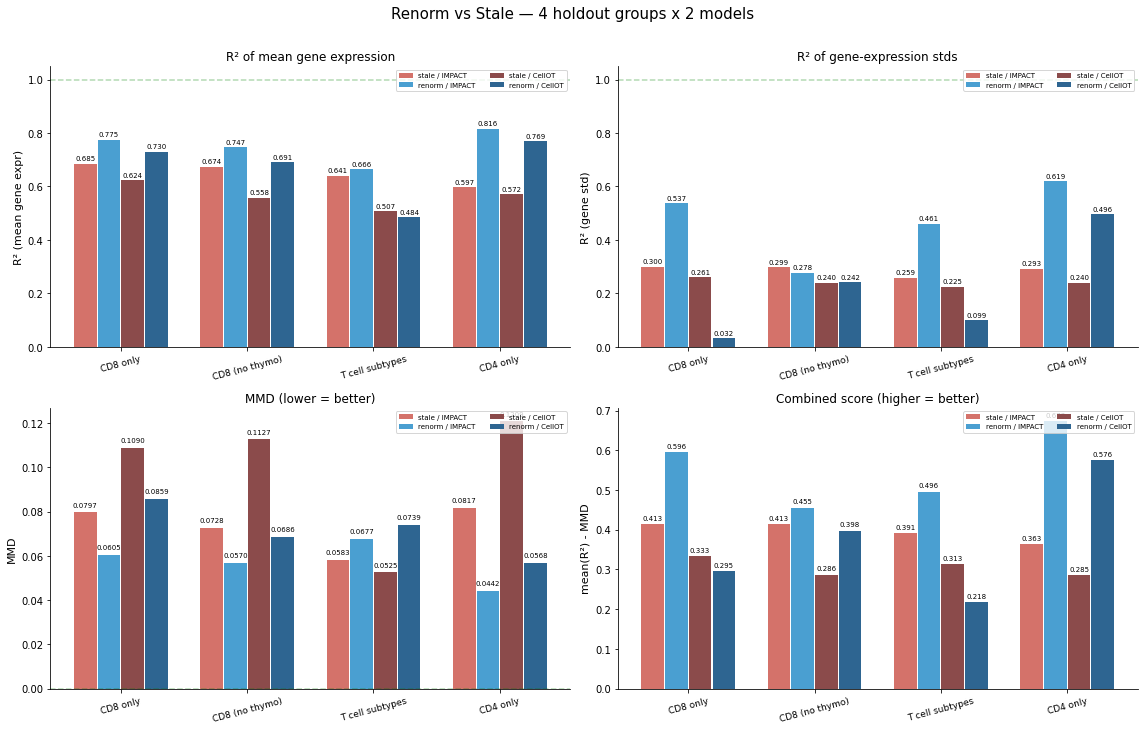

In [6]:
if len(results_df) > 0:
    COLOR = {
        ('stale',  'IMPACT'): '#D4726A',
        ('stale',  'CellOT'): '#8B4B4B',
        ('renorm', 'IMPACT'): '#4A9FD1',
        ('renorm', 'CellOT'): '#2E6591',
    }

    def bar_panel(ax, metric, ylabel, title, fmt="{:.3f}", label_off=0.01, ideal=None):
        slot_w = 0.9          # width allocated per family bar
        group_span = 2 * 2 * slot_w + 1.2  # 2 models x 2 families, +pad
        for gi, glabel in enumerate(GROUP_ORDER):
            for mi, model in enumerate(MODEL_ORDER):
                for fi, family in enumerate(FAMILY_ORDER):
                    row = results_df[
                        (results_df['group_label'] == glabel)
                        & (results_df['model'] == model)
                        & (results_df['run_family'] == family)
                    ]
                    if len(row) == 0:
                        continue
                    val = row[metric].values[0]
                    x = gi * group_span + mi * 2.0 * slot_w + fi * slot_w
                    color = COLOR[(family, model)]
                    lbl = f"{family} / {model}" if gi == 0 else None
                    ax.bar(x, val, width=slot_w * 0.95, color=color, label=lbl)
                    ax.text(x, val + label_off, fmt.format(val), ha='center', va='bottom', fontsize=7, rotation=0)
        xticks = [gi * group_span + 1.5 * slot_w for gi in range(len(GROUP_ORDER))]
        ax.set_xticks(xticks)
        ax.set_xticklabels(GROUP_ORDER, fontsize=9, rotation=15)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_title(title, fontsize=12)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        if ideal is not None:
            ax.axhline(y=ideal, color='green', linestyle='--', alpha=0.3)
        ax.legend(fontsize=7, loc='upper right', ncol=2)

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    bar_panel(axes[0, 0], 'r2_means', 'R² (mean gene expr)',  'R² of mean gene expression',    fmt="{:.3f}",  label_off=0.008, ideal=1.0)
    bar_panel(axes[0, 1], 'r2_stds',  'R² (gene std)',        'R² of gene-expression stds',    fmt="{:.3f}",  label_off=0.008, ideal=1.0)
    bar_panel(axes[1, 0], 'mmd',      'MMD',                  'MMD (lower = better)',          fmt="{:.4f}",  label_off=0.002, ideal=0.0)
    # Combined score panel: mean(R²) - MMD
    tmp = results_df.copy()
    tmp['score'] = 0.5 * (tmp['r2_means'].fillna(0) + tmp['r2_stds'].fillna(0)) - tmp['mmd'].fillna(0)
    combo = results_df.copy()
    combo['combo'] = 0.5 * (combo['r2_means'].fillna(0) + combo['r2_stds'].fillna(0)) - combo['mmd'].fillna(0)
    globals_bak = results_df
    try:
        globals()['results_df'] = combo
        bar_panel(axes[1, 1], 'combo', 'mean(R²) - MMD', 'Combined score (higher = better)', fmt="{:.3f}", label_off=0.008)
    finally:
        globals()['results_df'] = globals_bak

    plt.suptitle('Renorm vs Stale — 4 holdout groups x 2 models', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No results to plot yet.")

## 6. Best Experiment Identification (ranked within + across families)

Lower combined rank = better. R² rank ascending-reversed; MMD rank ascending.

In [7]:
if len(results_df) > 0:
    ranked = results_df.copy()
    ranked['r2_rank_global']  = ranked['r2_means'].rank(ascending=False)
    ranked['mmd_rank_global'] = ranked['mmd'].rank(ascending=True)
    ranked['combined_rank_global'] = ranked['r2_rank_global'] + ranked['mmd_rank_global']

    ranked['r2_rank_family']  = ranked.groupby('run_family')['r2_means'].rank(ascending=False)
    ranked['mmd_rank_family'] = ranked.groupby('run_family')['mmd'].rank(ascending=True)
    ranked['combined_rank_family'] = ranked['r2_rank_family'] + ranked['mmd_rank_family']

    ranked = ranked.sort_values('combined_rank_global')
    show_cols = ['run_family', 'group', 'group_label', 'model', 'r2_means', 'r2_stds', 'mmd',
                 'combined_rank_global', 'combined_rank_family']
    show_cols = [c for c in show_cols if c in ranked.columns]
    print("Top 5 globally:")
    display(ranked[show_cols].head(5).round(4))

    print("\nBottom 5 globally:")
    display(ranked[show_cols].tail(5).round(4))

    best = ranked.iloc[0]
    print(f"\nOverall best: {best['run_family']} / Group {best['group']} ({best['group_label']}) / {best['model']}")
    print(f"  R² means: {best['r2_means']:.4f}, R² stds: {best['r2_stds']:.4f}, MMD: {best['mmd']:.6f}")
else:
    print("No results to rank yet.")

Top 5 globally:


,run_family,group,group_label,model,r2_means,r2_stds,mmd,combined_rank_global,combined_rank_family
14,renorm,D,CD4 only,IMPACT,0.8157,0.6187,0.0442,2.0,2.0
15,renorm,D,CD4 only,CellOT,0.7694,0.4955,0.0568,6.0,5.0
8,renorm,A,CD8 only,IMPACT,0.7754,0.5371,0.0605,8.0,6.0
10,renorm,B,CD8 (no thymo),IMPACT,0.7466,0.2780,0.0570,8.0,7.0
11,renorm,B,CD8 (no thymo),CellOT,0.6909,0.2420,0.0686,14.0,12.0



Bottom 5 globally:


,run_family,group,group_label,model,r2_means,r2_stds,mmd,combined_rank_global,combined_rank_family
6,stale,D,CD4 only,IMPACT,0.5971,0.2925,0.0817,24.0,10.0
1,stale,A,CD8 only,CellOT,0.6239,0.2607,0.1090,25.0,10.0
13,renorm,C,T cell subtypes,CellOT,0.4841,0.0994,0.0739,26.0,15.0
3,stale,B,CD8 (no thymo),CellOT,0.5581,0.2401,0.1127,29.0,14.0
7,stale,D,CD4 only,CellOT,0.5720,0.2403,0.1209,29.0,14.0



Overall best: renorm / Group D (CD4 only) / IMPACT
  R² means: 0.8157, R² stds: 0.6187, MMD: 0.044189


## 7. Export Comparison Table to TSV

Saved to `autospeciesOT/results_renorm_vs_stale.tsv` for downstream use.

In [8]:
if len(results_df) > 0:
    out_dir = Path('/n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/autospeciesOT')
    out_dir.mkdir(parents=True, exist_ok=True)

    long_path = out_dir / 'results_renorm_vs_stale.tsv'
    export_cols = ['run_family', 'group', 'group_label', 'model', 'r2_means', 'r2_stds',
                   'l2_means', 'l2_stds', 'mmd', 'enrichment_k50']
    export_cols = [c for c in export_cols if c in results_df.columns]
    results_df[export_cols].to_csv(long_path, sep='\t', index=False)
    print(f"Long-form: {long_path}")

    delta_path = out_dir / 'results_renorm_vs_stale_delta.tsv'
    try:
        delta.reset_index().to_csv(delta_path, sep='\t', index=False)
        print(f"Delta:     {delta_path}")
    except NameError:
        print("(Delta not computed yet — rerun Section 4.)")
else:
    print("No results to export.")

Long-form: /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/autospeciesOT/results_renorm_vs_stale.tsv
Delta:     /n/holylabs/mooney_lab/Lab/junyizhou/speciesOT/autospeciesOT/results_renorm_vs_stale_delta.tsv


## 8. Summary and Takeaways

Fill in after running the notebook top-to-bottom:

- **Renorm vs stale on R² means**: `<wins_r2_means>/8` cells favor renorm
- **Renorm vs stale on R² stds**: `<wins_r2_stds>/8` cells favor renorm
- **Renorm vs stale on MMD**: `<wins_mmd>/8` cells favor renorm (lower)
- **Overall best cell**: `<family> / <group> / <model>`

### Interpretation notes

- The two families are NOT apples-to-apples: stale was evaluated in data space, renorm in latent space. Latent-space metrics tend to be more forgiving numerically for the CellOT family because imputation happens in 50-dim scGen space.
- The more meaningful comparison is internal consistency: does renorm rank the 8 (group, model) cells similarly to stale? A Spearman correlation between `combined_rank_stale` and `combined_rank_renorm` quantifies this.
- PTPRC (CD45) is legitimately not an HVG in the matched dataset (uniform across leukocytes). See §7 of `research_log_2026-04-20.txt` — neither pipeline should pick it up.

In [9]:
if len(results_df) > 0:
    r_stale = results_df[results_df['run_family'] == 'stale'].set_index(['group_label', 'model'])
    r_reno  = results_df[results_df['run_family'] == 'renorm'].set_index(['group_label', 'model'])
    joint = r_stale[['r2_means', 'mmd']].join(
        r_reno[['r2_means', 'mmd']], how='inner', lsuffix='_stale', rsuffix='_renorm'
    )
    if len(joint) >= 2:
        joint['rank_stale']  = joint['r2_means_stale'].rank(ascending=False)  + joint['mmd_stale'].rank(ascending=True)
        joint['rank_renorm'] = joint['r2_means_renorm'].rank(ascending=False) + joint['mmd_renorm'].rank(ascending=True)
        sp = joint[['rank_stale', 'rank_renorm']].corr(method='spearman').iloc[0, 1]
        print(f"Spearman rank correlation between stale and renorm (over {len(joint)} cells): {sp:+.3f}")
        display(joint.sort_values('rank_renorm').round(4))
    else:
        print("Need at least 2 matched cells to compute rank correlation.")
else:
    print("No results yet.")

Spearman rank correlation between stale and renorm (over 8 cells): -0.118


r2_means_stale  mmd_stale  r2_means_renorm  mmd_renorm  rank_stale  rank_renorm
group_label     model                                                                                  
CD4 only        IMPACT          0.5971     0.0817           0.8157      0.0442        10.0          2.0
                CellOT          0.5720     0.1209           0.7694      0.0568        14.0          5.0
CD8 only        IMPACT          0.6853     0.0797           0.7754      0.0605         5.0          6.0
CD8 (no thymo)  IMPACT          0.6736     0.0728           0.7466      0.0570         5.0          7.0
                CellOT          0.5581     0.1127           0.6909      0.0686        14.0         12.0
T cell subtypes IMPACT          0.6405     0.0583           0.6656      0.0677         5.0         12.0
CD8 only        CellOT          0.6239     0.1090           0.7298      0.0859        10.0         13.0
T cell subtypes CellOT          0.5073     0.0525           0.4841      0.0739         9.0         15.0